In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

files = sorted(glob.glob("*_visual_search_*.csv"))

all_players = []

for file in files:
    df = pd.read_csv(file)

    # Keep only correct target clicks
    df_correct = df[df["mouse.clicked_name"].astype(str).str.contains("target", na=False)]

    # Clean mouse.time column (remove brackets and convert to float)
    df_correct["mouse.time"] = (
        df_correct["mouse.time"]
        .str.strip("[]")
        .astype(float)
    )

    # Convert to milliseconds (if stored in seconds)
    df_correct["mouse.time"] *= 1000

    # Compute mean RT per color
    color_means = (
        df_correct
        .groupby("target_col")["mouse.time"]
        .mean()
    )

    # Ensure both colors exist
    color_means = color_means.reindex(["red", "white"])

    all_players.append(color_means.values)

data_matrix = np.array(all_players)

print("Data matrix shape:", data_matrix.shape)


Data matrix shape: (21, 2)


/tmp/ipykernel_311/157985401.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_correct["mouse.time"] = (
/tmp/ipykernel_311/157985401.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_correct["mouse.time"] *= 1000
/tmp/ipykernel_311/157985401.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

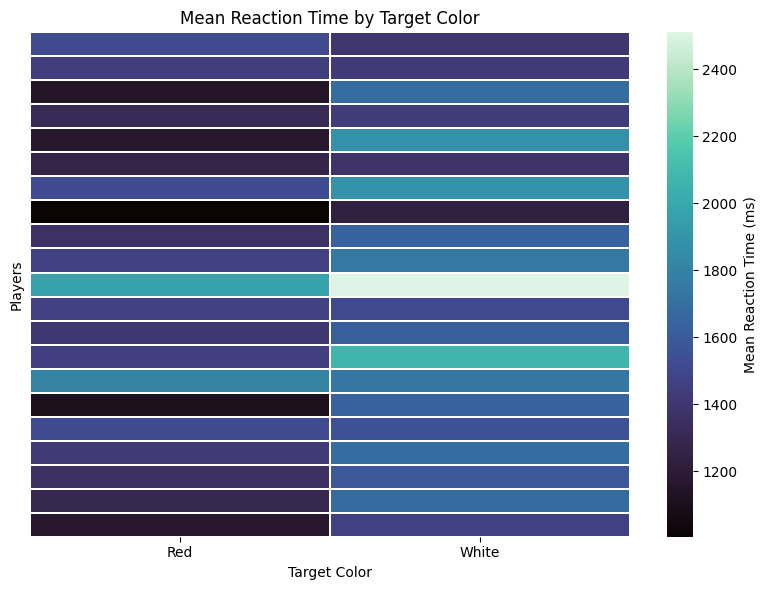

In [ ]:

plt.figure(figsize=(8,6))

sns.heatmap(
    data_matrix,
    cmap="mako",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={'label': 'Mean Reaction Time (ms)'},
    xticklabels=["Red", "White"],
    yticklabels=False
)

plt.xlabel("Target Color")
plt.ylabel("Players")
plt.title("Mean Reaction Time by Target Color")
plt.tight_layout()
plt.show()


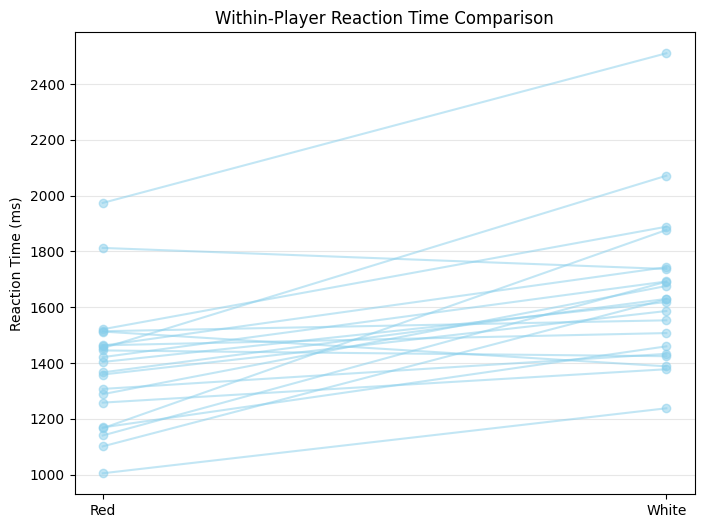

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(data_matrix, columns=["Red","White"])

plt.figure(figsize=(8,6))

for i in range(len(df)):
    plt.plot(
        ["Red","White"],
        df.iloc[i],
        marker='o',
        color='skyblue',
        alpha=0.5
    )

plt.ylabel("Reaction Time (ms)")
plt.title("Within-Player Reaction Time Comparison")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:

desc_stats = pd.DataFrame({
    "Mean_RT": np.nanmean(data_matrix, axis=0),
    "SD_RT": np.nanstd(data_matrix, axis=0),
    "Median_RT": np.nanmedian(data_matrix, axis=0),
    "Min_RT": np.nanmin(data_matrix, axis=0),
    "Max_RT": np.nanmax(data_matrix, axis=0)
}, index=["Red", "White"])

desc_stats


,Mean_RT,SD_RT,Median_RT,Min_RT,Max_RT
Red,1388.077105,219.748523,1404.02904,1005.25974,1973.91190
White,1654.076579,269.692083,1628.59374,1238.06668,2510.06876


In [ ]:
if df_correct.empty:
    print("No valid trials in:", file)

In [ ]:
desc_stats = pd.DataFrame({
    "Mean_RT": np.nanmean(data_matrix, axis=1),
    "SD_RT": np.nanstd(data_matrix, axis=1),
    "Median_RT": np.nanmedian(data_matrix, axis=1),
    "Min_RT": np.nanmin(data_matrix, axis=1),
    "Max_RT": np.nanmax(data_matrix, axis=1)
}, index=[f"Player_{i+1}" for i in range(data_matrix.shape[0])])

desc_stats

,Mean_RT,SD_RT,Median_RT,Min_RT,Max_RT
Player_1,1450.726835,62.259485,1450.726835,1388.46735,1512.98632
Player_2,1435.030070,10.361050,1435.030070,1424.66902,1445.39112
Player_3,1416.146600,275.519160,1416.146600,1140.62744,1691.66576
Player_4,1370.310850,62.837450,1370.310850,1307.47340,1433.14830
Player_5,1521.775930,355.070650,1521.775930,1166.70528,1876.84658
Player_6,1318.205960,59.794440,1318.205960,1258.41152,1378.00040
Player_7,1704.947610,183.705990,1704.947610,1521.24162,1888.65360
Player_8,1121.663210,116.403470,1121.663210,1005.25974,1238.06668
Player_9,1498.392915,131.727395,1498.392915,1366.66552,1630.12031
Player_10,1603.142815,140.497095,1603.142815,1462.64572,1743.63991


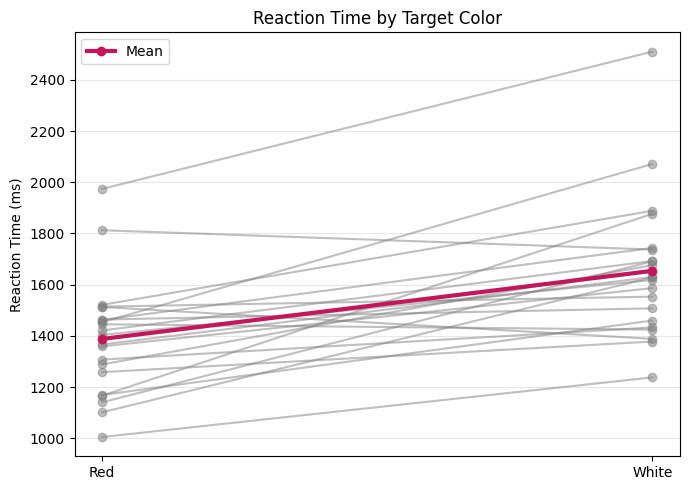

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(data_matrix, columns=["Red", "White"])

plt.figure(figsize=(7,5))

# Individual players
for i in range(len(df)):
    plt.plot(["Red","White"], df.iloc[i],
             color="gray", alpha=0.5, marker="o")

# Mean line
plt.plot(["Red","White"], df.mean(),
         color="#C2185B", marker="o",
         linewidth=3, label="Mean")

plt.ylabel("Reaction Time (ms)")
plt.title("Reaction Time by Target Color")
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

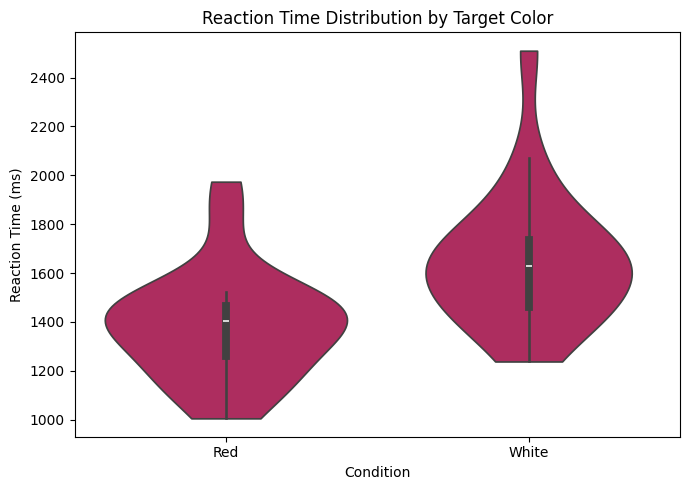

In [ ]:
import seaborn as sns

df_long = df.melt(var_name="Condition", value_name="RT")

plt.figure(figsize=(7,5))

sns.violinplot(
    data=df_long,
    x="Condition",
    y="RT",
    inner="box",
    color="#C2185B",
    cut=0
)

plt.ylabel("Reaction Time (ms)")
plt.title("Reaction Time Distribution by Target Color")

plt.tight_layout()
plt.show()

/tmp/ipykernel_311/3819842001.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vp = sns.violinplot(


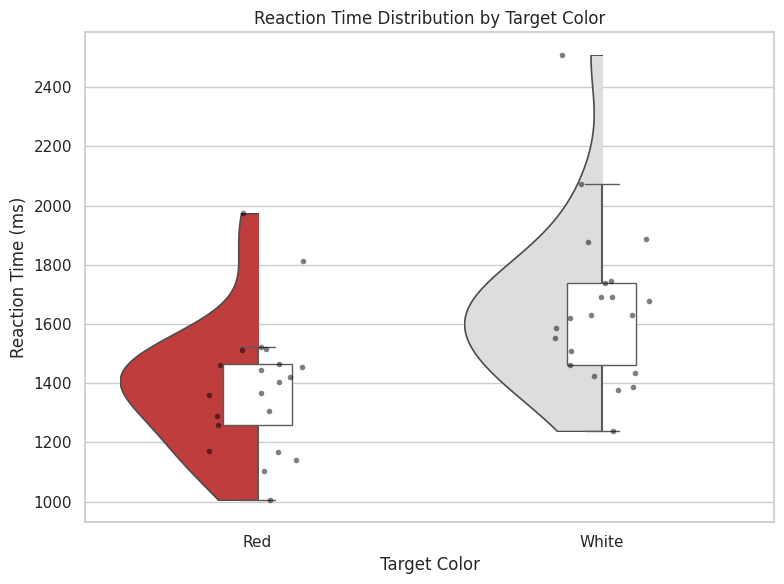

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(data_matrix, columns=["Red","White"])
df_long = df.melt(var_name="Condition", value_name="RT")

sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(8,6))

# Draw full violin
vp = sns.violinplot(
    data=df_long,
    x="Condition",
    y="RT",
    palette={"Red":"#d62728","White":"#dddddd"},
    inner=None,
    cut=0,
    linewidth=1.2,
    ax=ax
)

# Clip to half violin
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    violin.set_clip_path(plt.Rectangle(
        (bbox.x0, bbox.y0),
        (bbox.width/2),
        bbox.height,
        transform=ax.transData))

# Boxplot
sns.boxplot(
    data=df_long,
    x="Condition",
    y="RT",
    width=0.2,
    showcaps=True,
    boxprops={"facecolor":"white","zorder":3},
    whiskerprops={"linewidth":1.5},
    showfliers=False,
    ax=ax
)

# Scatter points
sns.stripplot(
    data=df_long,
    x="Condition",
    y="RT",
    color="black",
    size=4,
    alpha=0.5,
    jitter=0.15,
    ax=ax
)

plt.title("Reaction Time Distribution by Target Color")
plt.ylabel("Reaction Time (ms)")
plt.xlabel("Target Color")

plt.tight_layout()
plt.show()

/tmp/ipykernel_311/1806899618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


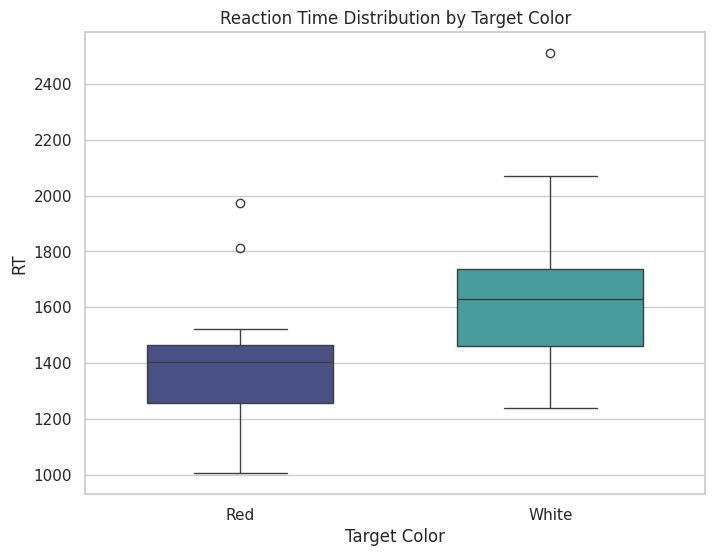

In [ ]:

df_long = pd.DataFrame(data_matrix, columns=["Red", "White"])
df_long = df_long.melt(var_name="Target Color", value_name="RT")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_long,
    x="Target Color",
    y="RT",
    palette="mako",
    width=0.6
)

plt.title("Reaction Time Distribution by Target Color")
plt.show()


/tmp/ipykernel_311/1554018644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


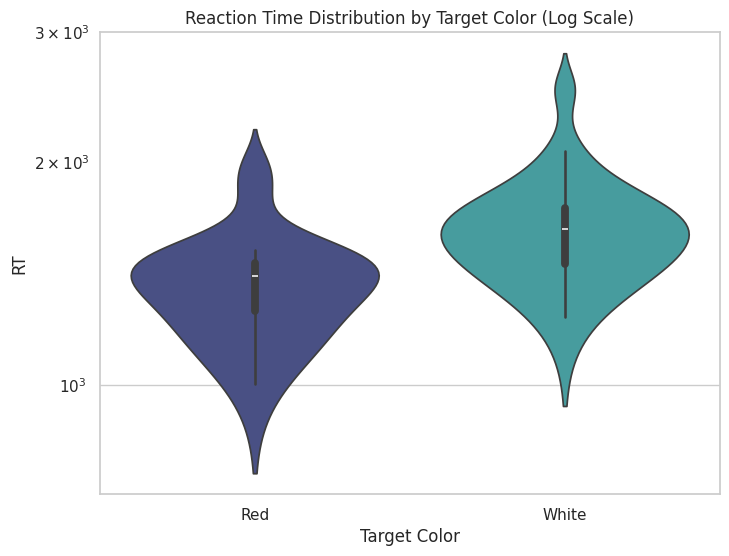

In [ ]:

plt.figure(figsize=(8,6))

sns.violinplot(
    data=df_long,
    x="Target Color",
    y="RT",
    palette="mako",
    inner="box"
)

plt.yscale("log")
plt.title("Reaction Time Distribution by Target Color (Log Scale)")
plt.show()


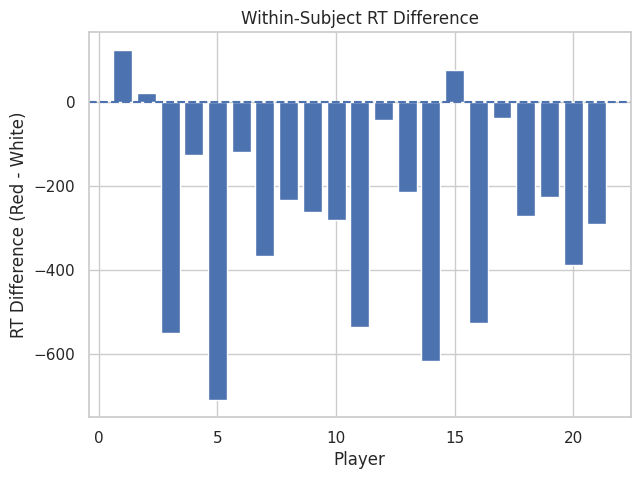

In [ ]:

difference = data_matrix[:,0] - data_matrix[:,1]

plt.figure(figsize=(7,5))
plt.bar(range(1, len(difference)+1), difference)

plt.axhline(0, linestyle='--')
plt.xlabel("Player")
plt.ylabel("RT Difference (Red - White)")
plt.title("Within-Subject RT Difference")
plt.show()


In [ ]:

from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(data_matrix[:,0], data_matrix[:,1])

print("Paired t-test Results")
print("t =", round(t_stat, 4))
print("p =", round(p_value, 4))


Paired t-test Results
t = -5.2753
p = 0.0


In [ ]:
all_trials = []

for file in files:
    df = pd.read_csv(file)

    df_correct = df[
        df["mouse.clicked_name"].astype(str).str.contains("target", na=False)
    ].copy()

    df_correct["RT"] = (
        df_correct["mouse.time"]
        .astype(str)
        .str.extract(r'([0-9.]+)')[0]
        .astype(float)
    )

    df_correct["RT"] *= 1000

    all_trials.append(df_correct[["target_col","RT"]])

df_trials = pd.concat(all_trials, ignore_index=True)

/tmp/ipykernel_311/3221945794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vp = sns.violinplot(


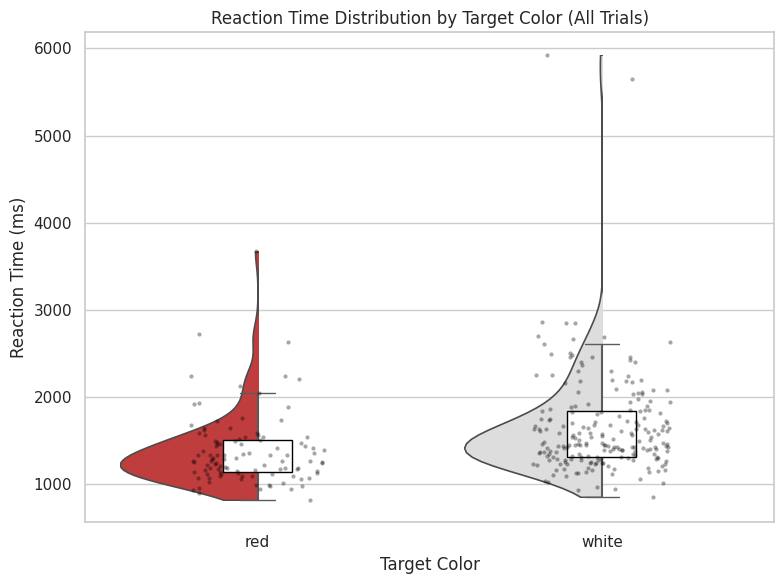

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(8,6))

vp = sns.violinplot(
    data=df_trials,
    x="target_col",
    y="RT",
    palette={"red":"#d62728","white":"#dddddd"},
    inner=None,
    cut=0,
    linewidth=1.2,
    ax=ax
)

# clip to half violin
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    violin.set_clip_path(plt.Rectangle(
        (bbox.x0, bbox.y0),
        bbox.width/2,
        bbox.height,
        transform=ax.transData))

sns.boxplot(
    data=df_trials,
    x="target_col",
    y="RT",
    width=0.2,
    showcaps=True,
    boxprops={"facecolor":"white","edgecolor":"black","zorder":3},
    whiskerprops={"linewidth":1.5},
    medianprops={"color":"black","linewidth":2},
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=df_trials,
    x="target_col",
    y="RT",
    color="black",
    size=3,
    alpha=0.35,
    jitter=0.2,
    ax=ax
)

plt.title("Reaction Time Distribution by Target Color (All Trials)")
plt.ylabel("Reaction Time (ms)")
plt.xlabel("Target Color")

plt.tight_layout()
plt.show()

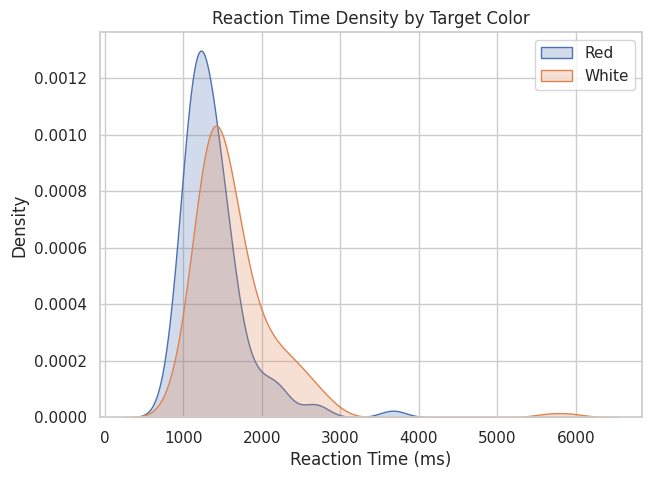

In [ ]:
plt.figure(figsize=(7,5))

sns.kdeplot(data=df_trials[df_trials.target_col=="red"]["RT"],
            fill=True, label="Red")

sns.kdeplot(data=df_trials[df_trials.target_col=="white"]["RT"],
            fill=True, label="White")

plt.xlabel("Reaction Time (ms)")
plt.title("Reaction Time Density by Target Color")
plt.legend()

plt.show()

<Axes: xlabel='RT', ylabel='Count'>

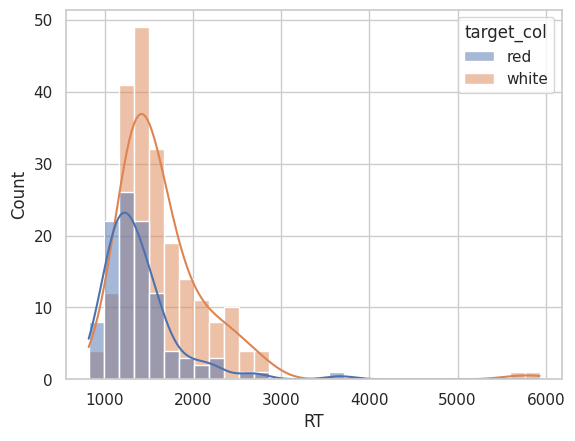

In [ ]:
sns.histplot(
    data=df_trials,
    x="RT",
    hue="target_col",
    bins=30,
    kde=True
)